### 1. GIỚI THIỆU BÀI TOÁN: Dự đoán cân nặng dựa trên chiều cao.

### 2. CƠ SỞ TOÁN HỌC
- Mô hình toán học: Giả sử cân nặng là một hàm bậc nhất theo chiều cao:
$$y \approx f(x) = \hat{y} = w_1 x + w_0$$
Trong đó: $w_1$ là trọng số (weight), $w_0$ là độ lệch (bias).
- Hàm mất mát (Loss Function): Giải thích việc tìm nghiệm chính là tìm điểm làm cực tiểu hàm mất mát (sai số bình phương):
$$\mathcal{L}(\mathbf{w}) = \frac{1}{2} \sum_{i=1}^N (y_i - \mathbf{x}_i \mathbf{w})^2 = \frac{1}{2} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2$$
- Công thức nghiệm: Nêu kết quả cuối cùng của việc lấy đạo hàm và giải phương trình đạo hàm bằng 0:
$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

### 3. VÍ DỤ

In [1]:
# Thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model

# Dữ liệu chiều cao (cm) và cân nặng (kg)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T

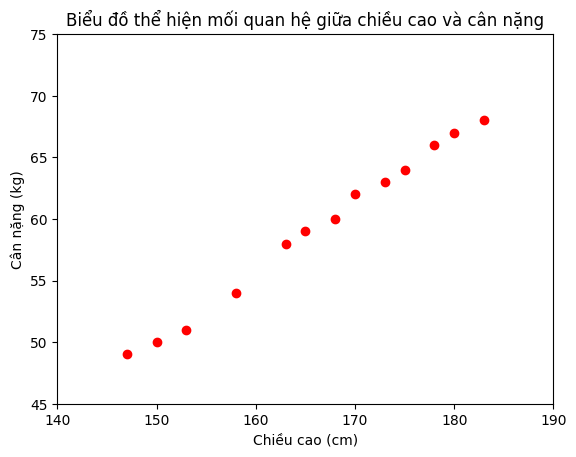

In [2]:
# Trực quan hóa dữ liệu
plt.plot(X, y, 'ro')
plt.axis([140, 190, 45, 75])
plt.xlabel('Chiều cao (cm)')
plt.ylabel('Cân nặng (kg)')
plt.title('Biểu đồ thể hiện mối quan hệ giữa chiều cao và cân nặng')
plt.show()

### 4. Giải bài toán bằng công thức toán học
-> Thực hiện tính toán nghiệm của bài toán bằng công thức ma trận đã nêu ở phần 2.

In [3]:
# Xây dựng ma trận Xbar bằng cách thêm cột 1 vào ma trận X
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis=1)

# Tính toán các trọng số w
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)

w_0 = w[0][0]
w_1 = w[1][0]
print(f'Nghiệm tính bằng công thức: w_0 = {w_0:.4f}, w_1 = {w_1:.4f}')

Nghiệm tính bằng công thức: w_0 = -33.7354, w_1 = 0.5592


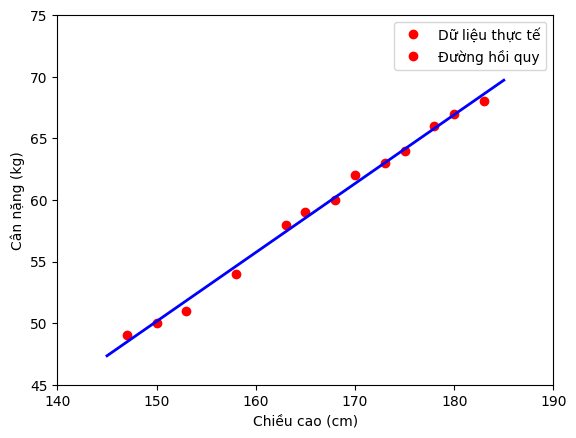

In [4]:
# Vẽ đường thẳng dự đoán
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1 * x0

plt.plot(X.T, y.T, 'ro')     # Dữ liệu thật
plt.plot(x0, y0, 'b-', linewidth=2)   # Đường thẳng dự đoán
plt.axis([140, 190, 45, 75])
plt.xlabel('Chiều cao (cm)')
plt.ylabel('Cân nặng (kg)')
plt.legend(['Dữ liệu thực tế', 'Đường hồi quy'])
plt.show()

### 5. Nghiệm tìm được bằng thư viện scikit-learn
-> Trong thực tế, ta sử dụng các thư viện tối ưu hóa sẵn có như scikit-learn để giải bài toán nhanh chóng và hiệu quả hơn, thay vì tự tính toán ma trận.

In [5]:
# Sử dụng scikit-learn
regr = linear_model.LinearRegression(fit_intercept=False) # fit_intercept=False vì đã thêm cột 1 vào Xbar
regr.fit(Xbar, y)

print(f'Nghiệm tính bằng scikit-learn: w_0 = {regr.coef_[0][0]:.4f}, w_1 = {regr.coef_[0][1]:.4f}')

Nghiệm tính bằng scikit-learn: w_0 = -33.7354, w_1 = 0.5592


### 6. Tổng kết
- Ưu điểm: Linear Regression đơn giản, tốc độ chạy nhanh, dễ hiểu và dễ triển khai.

- Nhược điểm: 
    + Rất nhạy cảm với nhiễu (outliers). Một điểm dữ liệu bất thường có thể làm chệch toàn bộ đường dự đoán.

    + Không thể hiện tốt các mối quan hệ phức tạp (phi tuyến tính).

- Kết luận: Phù hợp làm baseline model cho các bài toán phân tích dữ liệu đơn giản.

### 7. BÀI TẬP
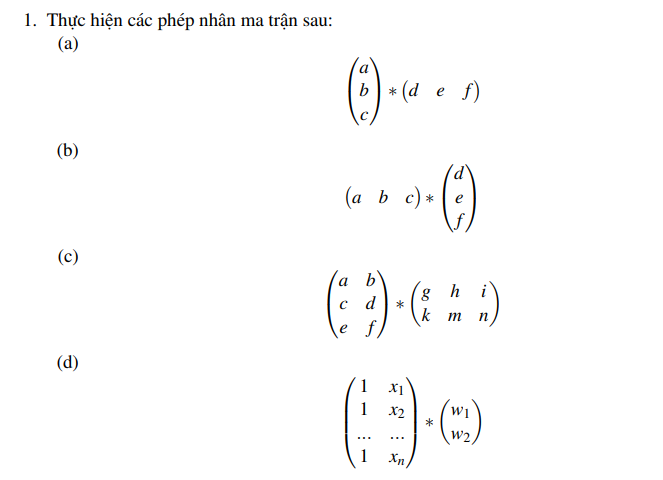

(a)$$\begin{pmatrix} a \\ b \\ c \end{pmatrix} * \begin{pmatrix} d & e & f \end{pmatrix} = 
\begin{pmatrix} 
ad & ae & af \\ 
bd & be & bf \\ 
cd & ce & cf 
\end{pmatrix}$$(b)$$\begin{pmatrix} a & b & c \end{pmatrix} * \begin{pmatrix} d \\ e \\ f \end{pmatrix} = ad + be + cf$$(c)$$\begin{pmatrix} a & b \\ c & d \\ e & f \end{pmatrix} * \begin{pmatrix} g & h & i \\ k & m & n \end{pmatrix} = 
\begin{pmatrix} 
ag+bk & ah+bm & ai+bn \\ 
cg+dk & ch+dm & ci+dn \\ 
eg+fk & eh+fm & ei+fn 
\end{pmatrix}$$(d)$$\begin{pmatrix} 1 & x_1 \\ 1 & x_2 \\ \dots & \dots \\ 1 & x_n \end{pmatrix} * \begin{pmatrix} w_1 \\ w_2 \end{pmatrix} = 
\begin{pmatrix} 
w_1 + w_2 x_1 \\ 
w_1 + w_2 x_2 \\ 
\dots \\ 
w_1 + w_2 x_n 
\end{pmatrix}$$

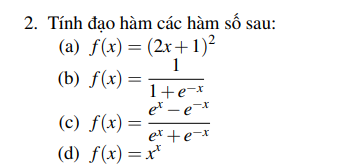

(a) $$f'(x) = 2(2x+1) \cdot 2 = 8x + 4$$

(b) $$f'(x) = \frac{-( -e^{-x} )}{(1+e^{-x})^2} = \frac{e^{-x}}{(1+e^{-x})^2} = f(x)(1 - f(x))$$

(c) $$f'(x) = \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2} = 1 - \left( \frac{e^x - e^{-x}}{e^x + e^{-x}} \right)^2 = 1 - f(x)^2$$

(d)
Lấy $\ln$ hai vế: 

$$\ln f(x) = x \ln x$$

Đạo hàm hai vế: 

$$\frac{f'(x)}{f(x)} = \ln x + x \cdot \frac{1}{x} = \ln x + 1$$

-> $$f'(x) = x^x(\ln x + 1)$$

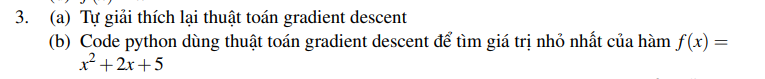

(a) Giải thích thuật toán:Gradient Descent là thuật toán tối ưu hóa lặp để tìm điểm cực tiểu của hàm số. Thuật toán bắt đầu từ một điểm $x$ khởi tạo ngẫu nhiên, sau đó cập nhật $x$ liên tục bằng cách bước lùi ngược hướng với đạo hàm (gradient) tại điểm đó. Kích thước mỗi bước nhảy được kiểm soát bởi tham số learning rate ($\eta$):$$x_{new} = x_{old} - \eta \cdot \nabla f(x_{old})$$

(b)

In [6]:
# Đạo hàm của hàm số là: f'(x) = 2x + 2
def grad(x):
    return 2 * x + 2

def gradient_descent(x_init, learning_rate, epochs):
    x = x_init
    for _ in range(epochs):
        x = x - learning_rate * grad(x)
    return x

# Khởi tạo x = 5, learning_rate = 0.1, lặp 100 lần
x_min = gradient_descent(x_init=5, learning_rate=0.1, epochs=100)
print(f"Giá trị x làm hàm nhỏ nhất là: {x_min:.5f}")

Giá trị x làm hàm nhỏ nhất là: -1.00000


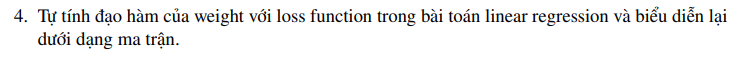

Hàm mất mát (Mean Squared Error) dạng ma trận:$$\mathcal{L}(\mathbf{w}) = \frac{1}{2} \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 = \frac{1}{2} (\mathbf{X}\mathbf{w} - \mathbf{y})^T(\mathbf{X}\mathbf{w} - \mathbf{y})$$Khai triển biểu thức:$$\mathcal{L}(\mathbf{w}) = \frac{1}{2} (\mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w} - \mathbf{w}^T\mathbf{X}^T\mathbf{y} - \mathbf{y}^T\mathbf{X}\mathbf{w} + \mathbf{y}^T\mathbf{y})$$Vì $\mathbf{y}^T\mathbf{X}\mathbf{w}$ là một số vô hướng nên nó bằng chuyển vị của chính nó $\mathbf{w}^T\mathbf{X}^T\mathbf{y}$, ta gộp lại:$$\mathcal{L}(\mathbf{w}) = \frac{1}{2} (\mathbf{w}^T\mathbf{X}^T\mathbf{X}\mathbf{w} - 2\mathbf{y}^T\mathbf{X}\mathbf{w} + \mathbf{y}^T\mathbf{y})$$Lấy đạo hàm theo vector trọng số $\mathbf{w}$:$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{2} (2\mathbf{X}^T\mathbf{X}\mathbf{w} - 2\mathbf{X}^T\mathbf{y}) = \mathbf{X}^T\mathbf{X}\mathbf{w} - \mathbf{X}^T\mathbf{y}$$Ghi gọn lại dưới dạng ma trận:$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \mathbf{X}^T(\mathbf{X}\mathbf{w} - \mathbf{y})$$

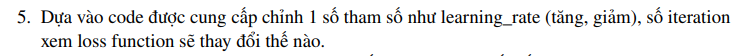

1. Thay đổi Learning Rate:
* Tăng quá lớn: Gradient Descent bước những bước quá dài, có thể nhảy vọt qua điểm cực tiểu. Hàm loss sẽ dao động lên xuống rất mạnh, thậm chí ngày càng tăng (thuật toán bị phân kỳ).
* Giảm quá nhỏ: Thuật toán di chuyển quá cẩn thận, mất rất nhiều thời gian để hội tụ. Hàm loss giảm rất chậm và nếu hàm phức tạp, thuật toán có nguy cơ mắc kẹt ở cực tiểu địa phương (local minimum).
* Vừa phải: Hàm loss giảm dần đều đặn qua mỗi vòng lặp và hội tụ ổn định về mức tối thiểu.

2. Thay đổi số vòng lặp:
* Quá ít: Thuật toán phải dừng lại trước khi chạm đến điểm cực tiểu (chưa hội tụ). Giá trị hàm loss vẫn còn cao và model dự đoán chưa chính xác.
* Quá nhiều: Khi thuật toán đã chạm đáy cực tiểu, hàm loss sẽ gần như không thay đổi nữa. Chạy thêm vòng lặp lúc này chỉ làm lãng phí thời gian và tài nguyên máy tính.

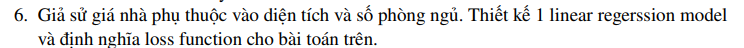

1. Thiết kế Model:
Giả sử $y$ là giá nhà, $x_1$ là diện tích, và $x_2$ là số phòng ngủ. Bài toán này có nhiều hơn một biến đầu vào, nên ta dùng Hồi quy tuyến tính đa biến (Multiple Linear Regression).

Mô hình dự đoán có dạng:
    
$$\hat{y} = w_1x_1 + w_2x_2 + w_0$$
    
*Trong đó:* * $w_1, w_2$ là trọng số (weights) của đặc trưng diện tích và số phòng ngủ.
* $w_0$ là độ lệch (bias).

Viết gọn dưới dạng ma trận: $\mathbf{\hat{y}} = \mathbf{X}\mathbf{w}$

2. Định nghĩa Loss Function:
Ta vẫn sử dụng hàm Sai số toàn phương trung bình (Mean Squared Error - MSE) để đo lường chênh lệch giữa giá thực tế và giá dự đoán:
    
$$\mathcal{L}(\mathbf{w}) = \frac{1}{2N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2 = \frac{1}{2N} \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2$$